In [16]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd 
import time
import torch
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix
from sklearn.metrics import confusion_matrix, roc_curve, auc, log_loss
from sklearn.preprocessing import label_binarize
from utils.funciones_minio import bajar_minio,crear_cliente_minio

In [17]:
def visualizar_matriz_confusion(y_test, y_pred, nombre_modelo, clases=['Cocina', 'Dormitorio', 'Salón', 'Banyo']):
    cm = confusion_matrix(y_test, y_pred)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=clases, yticklabels=clases,
                annot_kws={"size": 14, "weight": "bold"}) 
    
    plt.title(f'Matriz de Confusión - {nombre_modelo}', fontsize=16, pad=20, weight='bold')
    plt.ylabel('Etiqueta Real', fontsize=12, weight='bold')
    plt.xlabel('Predicción', fontsize=12, weight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

In [18]:
def visualizar_curva_roc(y_test, y_score, nombre_modelo, clases=['Cocina', 'Dormitorio', 'Salón', 'Banyo']):
    y_test_bin = label_binarize(y_test, classes=range(len(clases)))
    
    plt.figure(figsize=(9, 7))
    sns.set_style("whitegrid")
    colores = ['#e63946', '#2a9d8f', '#e9c46a', '#264653']
    
    for i, color in enumerate(colores):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, color=color, lw=2.5, label=f'{clases[i]} (AUC = {roc_auc:.3f})')
        
    plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Azar (AUC = 0.500)')
    plt.xlim([-0.02, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Tasa de Falsos Positivos (FPR)', weight='bold')
    plt.ylabel('Tasa de Verdaderos Positivos (TPR)', weight='bold')
    plt.title(f'Curvas ROC - {nombre_modelo}', fontsize=16, pad=20, weight='bold')
    plt.legend(loc="lower right", frameon=True, shadow=True)
    plt.tight_layout()
    plt.show()

In [ ]:
def evaluar_log_loss(y_test, y_score, nombre_modelo):
    if "SVC" in nombre_modelo or "Support Vector" in nombre_modelo:
        print(f" {nombre_modelo} usa fronteras de decisión (distancias), no probabilidades. Log Loss no aplicable.")
        return None
        
    valor_log_loss = log_loss(y_test, y_score)
    print(f" Log Loss para {nombre_modelo}: {valor_log_loss:.4f}")
    return valor_log_loss

In [20]:
def obtener_predicciones(modelo, X_test):
    """
    Habla con cualquier modelo y extrae de forma segura sus predicciones.
    Devuelve:
      - y_pred: Array 1D con las clases predichas (ej: [2, 0, 1, 3...])
      - y_score: Array 2D con las probabilidades o distancias.
    """
    if hasattr(modelo, "predict_proba"):
        y_score = modelo.predict_proba(X_test)
    elif hasattr(modelo, "decision_function"):
        y_score = modelo.decision_function(X_test)
    else:
        try:
            y_score = modelo.predict(X_test, verbose=0)
        except TypeError:
            y_score = modelo.predict(X_test) 

    
    if hasattr(modelo, "predict_proba") or hasattr(modelo, "decision_function"):
        y_pred = modelo.predict(X_test)
    else:
        y_pred = np.argmax(y_score, axis=1)
        
    return y_pred, y_score

In [21]:
def preparar_dataset(df:pd.DataFrame):
    df = df[df["clase"] != "Comedor"]
    X = np.stack(df['embedding'].values)
    codificador = LabelEncoder()
    y = codificador.fit_transform(df['clase'])  
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=101, stratify=y)
    print(f"Formato datos de train: {X_train.shape}")
    print(f"Formato datos de test: {X_test.shape}")
    return X_train,X_test,y_train,y_test

In [23]:
cliente = crear_cliente_minio()
ruta_ml = "dataset_ml"
fichero = "embeddings_imagenes.parquet"
df = bajar_minio(cliente, ruta_ml, fichero)
X_train,X_test,y_train,y_test = preparar_dataset(df)

Formato datos de train: (135380, 2048)
Formato datos de test: (33845, 2048)


In [7]:
class PyTorchWrapper:
    """Engaña a las funciones de gráficas para que traten a PyTorch como si fuera Keras"""
    def __init__(self, modelo):
        self.modelo = modelo
        self.modelo.eval()
    
    def predict(self, X, verbose=0):
        with torch.no_grad():
            tensor_X = torch.tensor(X.astype(np.float32))
            return self.modelo(tensor_X).numpy()
            
    # Le ponemos este nombre para que las gráficas lo reconozcan bonito
    @property
    def __class__(self):
        class _Proxy:
            __name__ = "Mini Red (SoftMax - PyTorch)"
        return _Proxy()

In [8]:
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

class ClasificadorEmbeddings(nn.Module):
    """
        Genera el modelo de pytorch con la capa densa para la clasificación
    """
    def __init__(self, num_clases=4):
        """
            Inicio de la red neuronal con su configuracion de una capa densa
        Args:
            num_clases (int, optional): Numero de clases que queremos clasificar. Defaults to 4.
        """
        super().__init__()
        self.capa_final = nn.Linear(2048, num_clases)

    def forward(self, x):
        """
            Funcion de forward que pasa los datos x recibidos por la ultima capa de embedings de resnet por la capa densa nuestra
        Args:
            x (Tensor): Lista de embedings recibida para una serie de imagenes a clasificar

        Returns:
            Tensor: Valores obtenidos para las 4 distintas clases
        """
        return self.capa_final(x)

def entrenar_mini_red(X_train, y_train, X_test, y_test, num_clases=4, epochs=50, batch_size=256):
    """
        Entrena un algoritmo de softmax con una red neuronal de una sola capa que aprovecha los embedings de
        Resnet 50 para traducirlos a probabilidades de cada clase 
    Args:
        X_train (np.array): conjunto x de train
        y_train (np.array): conjunto y de train
        X_test (np.array): conjunto x de test
        y_test (np.array): conjunto y de test
        num_clases (int, optional): numero de clases de habitaciones. Defaults to 4.
        epochs (int, optional): numero de epocas de entrenamiento. Defaults to 50.
        batch_size (int, optional): cantidad de imagenes que se pasan en un paso del entrenamiento. Defaults to 256.

    Returns:
        nn.Modelo: modelo softmax
    """
    X_train_tensor = torch.tensor(X_train.astype(np.float32))
    y_train_tensor = torch.tensor(y_train, dtype=torch.long)
    X_test_tensor = torch.tensor(X_test.astype(np.float32))
    y_test_tensor = torch.tensor(y_test, dtype=torch.long)
    
    dataset_train = TensorDataset(X_train_tensor, y_train_tensor)
    loader_train = DataLoader(dataset_train, batch_size=batch_size, shuffle=True)
    
    modelo = ClasificadorEmbeddings(num_clases=num_clases)
    # el criterio crossentropyloss hace su propio softmax internamente por eso no lo metemos antes
    criterio = nn.CrossEntropyLoss() 
    optimizador = torch.optim.Adam(modelo.parameters(), lr=0.001)
    
    
    for epoch in range(epochs):
        modelo.train()
        loss_total_train = 0
        
        for batch_X, batch_y in loader_train:
            optimizador.zero_grad()          
            predicciones = modelo(batch_X)  
            loss = criterio(predicciones, batch_y) 
            loss.backward()                   
            optimizador.step()              
            
            loss_total_train += loss.item()
            
        loss_media_train = loss_total_train / len(loader_train)
        
        modelo.eval()
        with torch.no_grad(): 
            predicciones_test = modelo(X_test_tensor)
            loss_test = criterio(predicciones_test, y_test_tensor).item()
            
            _, predicciones_clases = torch.max(predicciones_test, 1)
            
            
        print(f"Epoch [{epoch+1}/{epochs}] | Loss Train: {loss_media_train:.4f} | Loss Test: {loss_test:.4f} | Acc Test: {acc_test*100:.2f}%")
        
        

    modelo_produccion = nn.Sequential(
        modelo,
        nn.Softmax(dim=1)
    )


    return modelo_produccion

In [9]:
inicio = time.time()
mejor_knn = KNeighborsClassifier(
    n_neighbors=18,
    weights='distance',
    metric='euclidean',
    n_jobs=-1
)
mejor_knn.fit(X_train, y_train)

print(f" KNN listo en {time.time() - inicio:.2f} segundos.")

 KNN listo en 2.69 segundos.


In [10]:
inicio = time.time()

mejor_svc = LinearSVC(
    C=0.0034466743854557535,
    random_state=101,
    max_iter=5000,
    dual="auto"
)
mejor_svc.fit(X_train, y_train)

print(f" Linear SVC listo en {time.time() - inicio:.2f} segundos.")



 Linear SVC listo en 111.36 segundos.


In [ ]:
inicio = time.time()

mejor_mlp = MLPClassifier(
    hidden_layer_sizes=(1024, 512), 
    learning_rate_init=0.0001,
    random_state=101,
    max_iter=500 
)
mejor_mlp.fit(X_train, y_train)

print(f" MLP listo en {time.time() - inicio:.2f} segundos.")

In [ ]:
print("\n Entrenando Mini Red (SoftMax)...")
inicio = time.time()
modelo_softmax = entrenar_mini_red(
    X_train, y_train, X_test, y_test, 
    num_clases=4, 
    epochs=10, 
    batch_size=256
)
print(f" SoftMax listo en {time.time() - inicio:.2f} segundos.")

Generando predicciones con: KNeighborsClassifier...


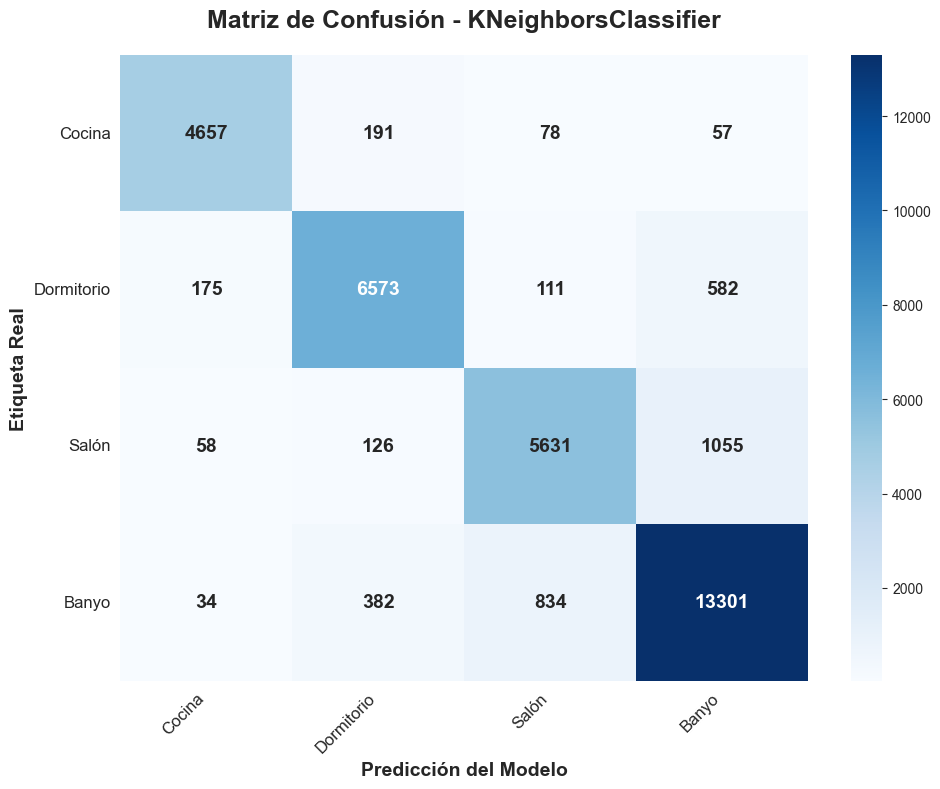

Calculando las curvas ROC para: KNeighborsClassifier...


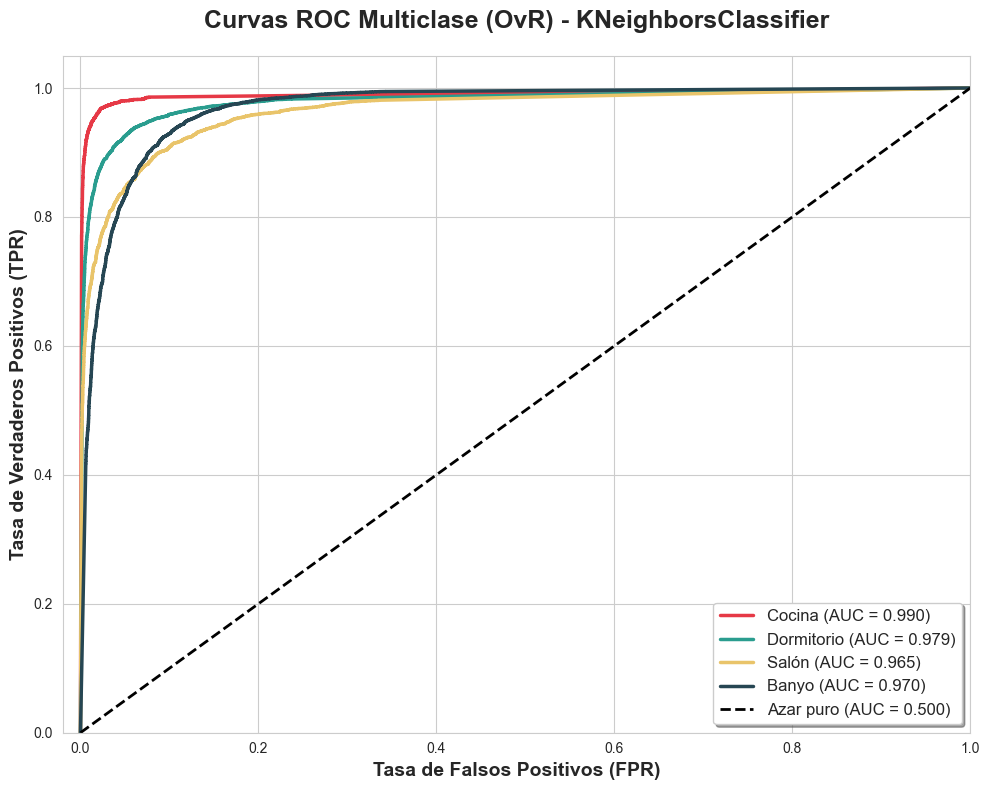

Calculando Log Loss para: KNeighborsClassifier...
 Resultado Log Loss: 0.6736


0.6735763004085316

In [14]:
visualizar_matriz_confusion(mejor_knn,X_test,y_test)
visualizar_curva_roc(mejor_knn,X_test,y_test)
evaluar_log_loss(mejor_knn,X_test,y_test)

Generando predicciones con: LinearSVC...


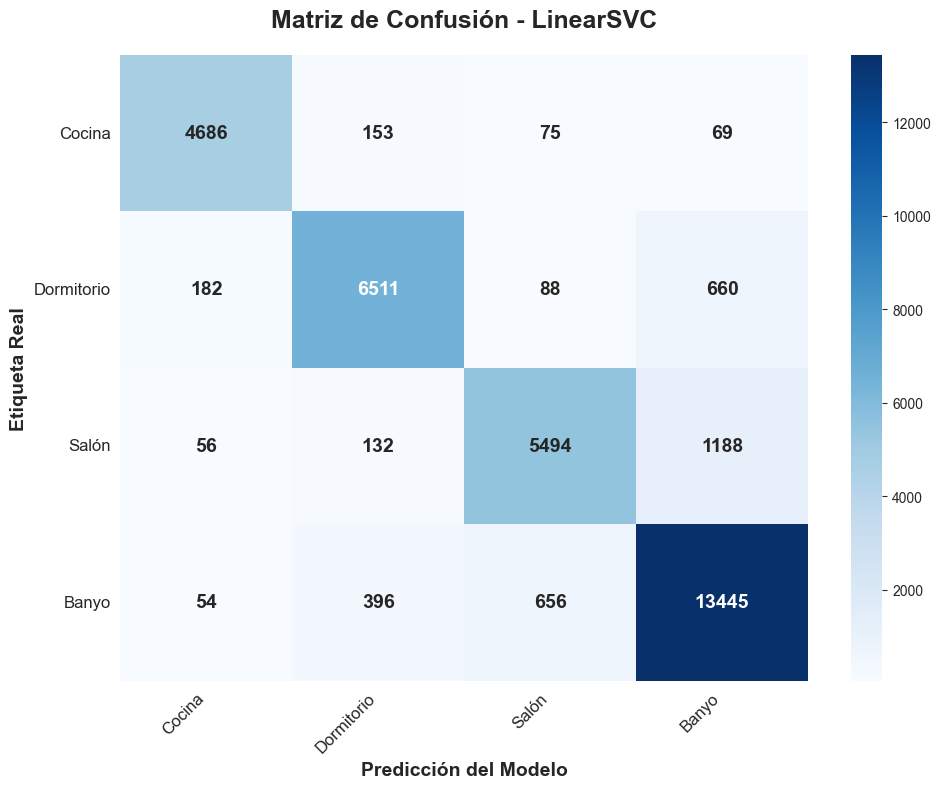

Calculando las curvas ROC para: LinearSVC...


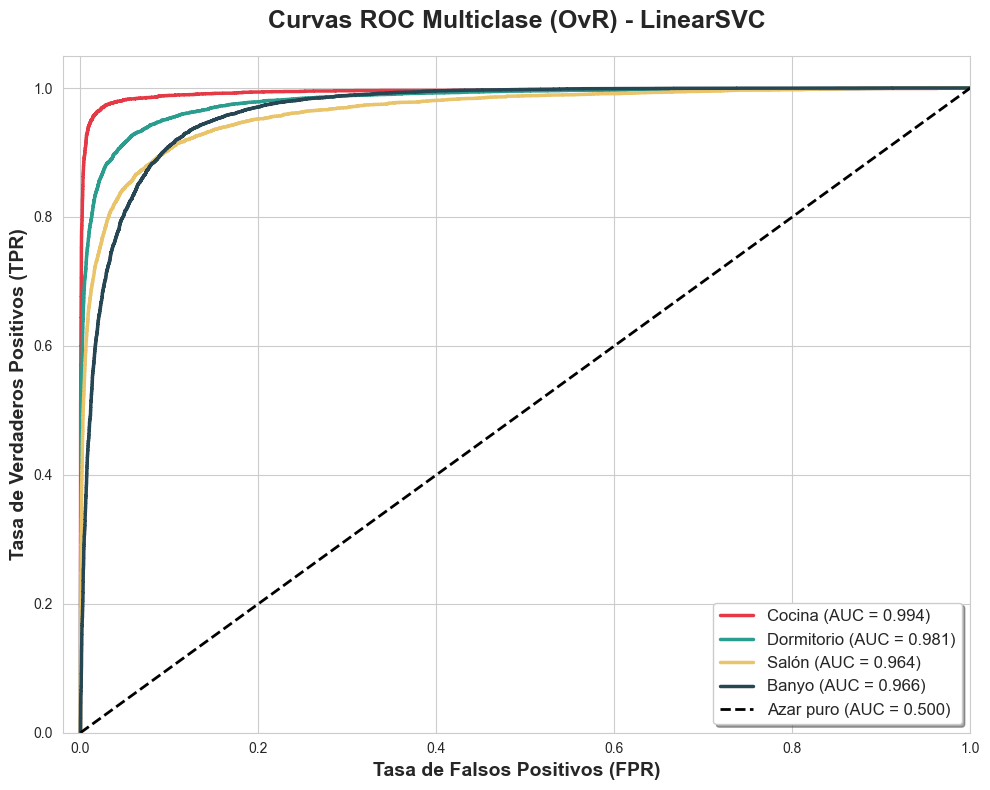

Calculando Log Loss para: LinearSVC...


TypeError: LinearClassifierMixin.predict() got an unexpected keyword argument 'verbose'

In [15]:
visualizar_matriz_confusion(mejor_svc,X_test,y_test)
visualizar_curva_roc(mejor_svc,X_test,y_test)
evaluar_log_loss(mejor_svc,X_test,y_test)

In [ ]:
visualizar_matriz_confusion(mejor_mlp,X_test,y_test)
visualizar_curva_roc(mejor_mlp,X_test,y_test)
evaluar_log_loss(mejor_mlp,X_test,y_test)

In [ ]:
visualizar_matriz_confusion(modelo_softmax ,X_test,y_test)
visualizar_curva_roc(modelo_softmax ,X_test,y_test)
evaluar_log_loss(modelo_softmax ,X_test,y_test)